In [22]:
import numpy as np
import os
import importlib
import uxarray as ux
from plotting_functions import *

In [7]:
# Grid
grid_path_SCRIP = '/glade/u/home/nforcone/MidwestVarRes/midwest-06-16-2025_edit22_np4_SCRIP.nc'

# microp_true
run_dir_microp_true = '/glade/work/nforcone/August2020data/run_data/ZM_on_microp_uniform'

true34560 = 'StormSPEED.stormspeed_refmesh_FHISTC_LTso_ne0MIDWESTne30x32_ne0MIDWESTne30x32_20200810_land_ZM_on_microp_uniform.cam.h0i.2020-08-10-34560.nc'
true46080 = 'StormSPEED.stormspeed_refmesh_FHISTC_LTso_ne0MIDWESTne30x32_ne0MIDWESTne30x32_20200810_land_ZM_on_microp_uniform.cam.h0i.2020-08-10-46080.nc'
true57600 = 'StormSPEED.stormspeed_refmesh_FHISTC_LTso_ne0MIDWESTne30x32_ne0MIDWESTne30x32_20200810_land_ZM_on_microp_uniform.cam.h0i.2020-08-10-57600.nc'
true69120 = 'StormSPEED.stormspeed_refmesh_FHISTC_LTso_ne0MIDWESTne30x32_ne0MIDWESTne30x32_20200810_land_ZM_on_microp_uniform.cam.h0i.2020-08-10-69120.nc'
true_paths = [os.path.join(run_dir_microp_true, true34560),
              os.path.join(run_dir_microp_true, true46080),
              os.path.join(run_dir_microp_true, true57600),
              os.path.join(run_dir_microp_true, true69120)]

uxds_microp_true = ux.open_mfdataset(grid_path_SCRIP, true_paths)

In [10]:
my_xlims = (-95, -85)
my_ylims = (39, 45)

U500 = SubsetLatLon(uxds_microp_true, "U500", my_xlims, my_ylims)
V500 = SubsetLatLon(uxds_microp_true, "V500", my_xlims, my_ylims)
Z500 = Hybrid2plev(uxds_microp_true, "Z3", my_xlims, my_ylims,
                   np.asarray([50000.]),
                   "log",
                   True)
Z200 = Hybrid2plev(uxds_microp_true, "Z3", my_xlims, my_ylims,
                   np.asarray([20000.]),
                   "log",
                   True)

In [15]:
Z500_bounds = np.arange(5760, 5912, 10)
Z500_bounds

array([5760, 5770, 5780, 5790, 5800, 5810, 5820, 5830, 5840, 5850, 5860,
       5870, 5880, 5890, 5900, 5910])

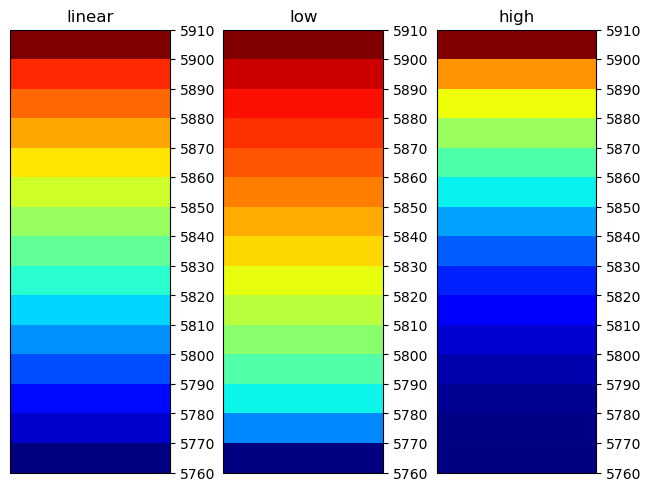

In [34]:
importlib.reload(plotting_functions)
from plotting_functions import *
Z500_color_norm, Z500_lin_cm, _, _ = ListedCMAP_Wrapper(Z500_bounds, 'jet')